In [38]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

In [39]:
df=pd.read_csv('Housing_data.csv')

In [40]:
df

,Price,LivingArea,Bathrooms,Bedrooms,LotSize,Age,Fireplace
0,16858,1629,1.0,3,0.76,180,0
1,26049,1344,2.0,3,0.92,13,0
2,26130,822,1.0,2,0.56,173,0
3,31113,1540,1.0,2,0.04,115,0
4,40932,1320,1.0,3,0.17,90,0
...,...,...,...,...,...,...,...
1042,387652,3504,2.5,5,0.90,0,1
1043,391842,3003,3.5,4,0.46,88,1
1044,394532,3361,3.5,4,0.71,1,1
1045,432845,3250,2.5,3,0.53,23,1


In [41]:
df.shape

(1047, 7)

In [42]:
df.head()

,Price,LivingArea,Bathrooms,Bedrooms,LotSize,Age,Fireplace
0,16858,1629,1.0,3,0.76,180,0
1,26049,1344,2.0,3,0.92,13,0
2,26130,822,1.0,2,0.56,173,0
3,31113,1540,1.0,2,0.04,115,0
4,40932,1320,1.0,3,0.17,90,0


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1047 entries, 0 to 1046
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Price       1047 non-null   int64  
 1   LivingArea  1047 non-null   int64  
 2   Bathrooms   1047 non-null   float64
 3   Bedrooms    1047 non-null   int64  
 4   LotSize     1047 non-null   float64
 5   Age         1047 non-null   int64  
 6   Fireplace   1047 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 57.4 KB


In [44]:
df.isnull().sum()

Price         0
LivingArea    0
Bathrooms     0
Bedrooms      0
LotSize       0
Age           0
Fireplace     0
dtype: int64

In [45]:
df.duplicated().sum()

np.int64(12)

In [46]:
df.drop_duplicates(inplace=True,ignore_index=True)

In [47]:
df.duplicated().sum()

np.int64(0)

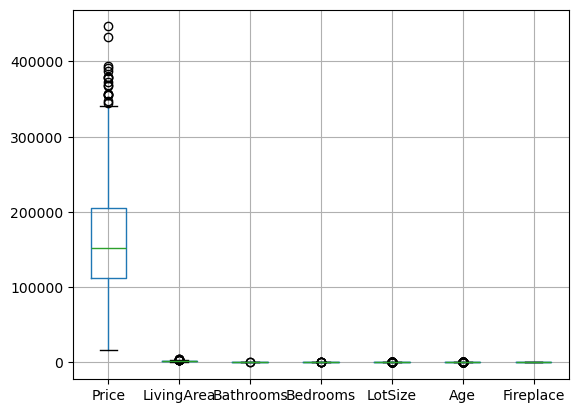

In [48]:
## Checking the outliers
df.boxplot()
plt.show()

In [49]:
### Outlier capping
def outlier_capping(df,column):
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR=Q3-Q1
    lower_extreme=Q1-1.5*IQR
    upper_extreme=Q3-1.5*IQR
    df[column]=df[column].apply(lambda x:x if x>=lower_extreme else x if x<= upper_extreme else x)
for col in df.select_dtypes(['int','float']).columns:
    outlier_capping(df,col)

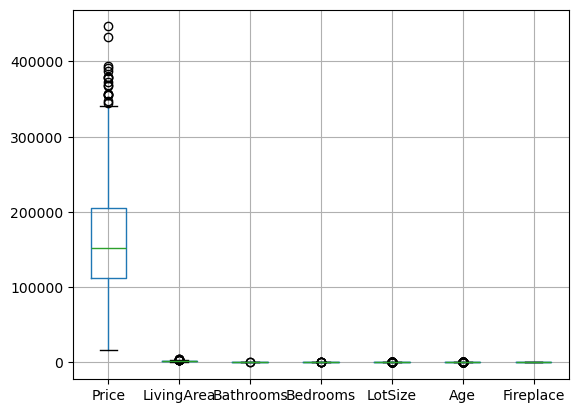

In [50]:
df.boxplot()
plt.show()

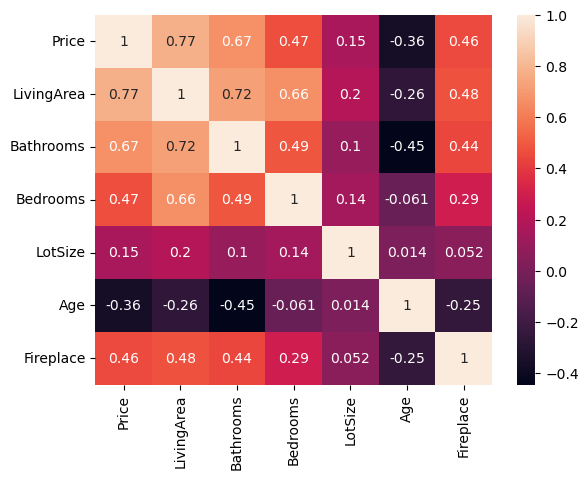

In [51]:
### Feature selection
corr=df.corr()
sns.heatmap(corr,annot=True)
plt.show()

In [52]:
target=df[['Price']]
features=df.drop(columns=['Price'])

In [53]:
### Multicolinearity
### Variance_inflation_factor
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [54]:
vif=pd.DataFrame()
vif['features']=features.columns
vif['VIF']=[variance_inflation_factor(features.values,i)for i in range(len(features.columns))]
features.values

array([[1.629e+03, 1.000e+00, 3.000e+00, 7.600e-01, 1.800e+02, 0.000e+00],
       [1.344e+03, 2.000e+00, 3.000e+00, 9.200e-01, 1.300e+01, 0.000e+00],
       [8.220e+02, 1.000e+00, 2.000e+00, 5.600e-01, 1.730e+02, 0.000e+00],
       ...,
       [3.361e+03, 3.500e+00, 4.000e+00, 7.100e-01, 1.000e+00, 1.000e+00],
       [3.250e+03, 2.500e+00, 3.000e+00, 5.300e-01, 2.300e+01, 1.000e+00],
       [3.467e+03, 2.500e+00, 4.000e+00, 3.400e-01, 3.000e+00, 1.000e+00]])

In [55]:
vif.sort_values(by='VIF',ascending=False)

,features,VIF
0,LivingArea,27.044060
2,Bedrooms,23.859287
1,Bathrooms,21.075034
5,Fireplace,3.308330
4,Age,1.890116
3,LotSize,1.609732


In [56]:
for i in range(len(features.columns)):
    print(i)

0
1
2
3
4
5


In [57]:
from sklearn.feature_selection import f_regression
import warnings
warnings.filterwarnings('ignore')

In [58]:
f_reg=f_regression(features,target)

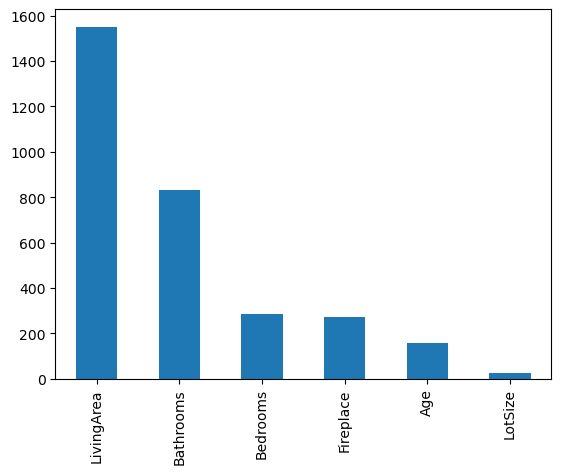

In [59]:
pd.Series(f_reg[0],index=features.columns).sort_values(ascending=False).plot(kind='bar')
plt.show()

In [60]:
features.drop(columns=['LotSize'],inplace=True)

In [61]:
features.head()

,LivingArea,Bathrooms,Bedrooms,Age,Fireplace
0,1629,1.0,3,180,0
1,1344,2.0,3,13,0
2,822,1.0,2,173,0
3,1540,1.0,2,115,0
4,1320,1.0,3,90,0


In [62]:
###Scaling
from sklearn.preprocessing import StandardScaler,MinMaxScaler,OneHotEncoder,OrdinalEncoder,RobustScaler,LabelEncoder
std_sca=StandardScaler()
features[['LivingArea','Age']]=std_sca.fit_transform(features[['LivingArea','Age']])

In [63]:
x_train,x_test,y_train,y_test=train_test_split(features,target,train_size=0.85,random_state=100)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(879, 5)
(156, 5)
(879, 1)
(156, 1)


In [64]:
lin_model=LinearRegression()
lin_model.fit(x_train,y_train)

LinearRegression()

In [65]:
lin_model.intercept_

array([142672.81758183])

In [66]:
lin_model.coef_

array([[42189.04870006, 16501.56617625, -4989.27142412, -7112.11816938,
         9837.95072209]])

In [67]:
### Training Validation
### training validation
y_pred=lin_model.predict(x_train)
r2_score(y_train,y_pred)

0.6378523161412953

In [68]:
## Testing Validation
y_pred1=lin_model.predict(x_test)
r2_score(y_test,y_pred1)

0.6732481191513653

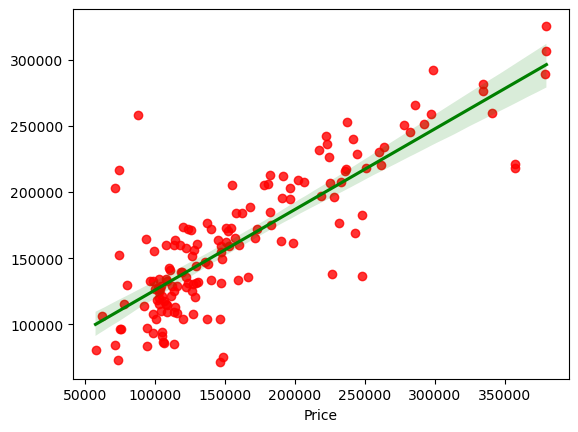

In [69]:
import seaborn as sns
sns.regplot(x=y_test,y=y_pred1,scatter_kws={'color':'red'},line_kws={'color':'green'})
plt.show()

In [72]:
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error,mean_squared_error 

In [73]:
np.round(mean_absolute_error(y_test,y_pred1),2)

np.float64(29186.4)

In [75]:
mse=np.round(mean_squared_error(y_test,y_pred1),2)
mse

np.float64(1722265693.48)

In [76]:
mape=np.round(mean_absolute_percentage_error(y_test,y_pred1),2)*100
mape

np.float64(21.0)

In [77]:
r_squ=r2_score(y_test,y_pred1)
r_squ

0.6732481191513653

In [80]:
features.shape

(1035, 5)

In [81]:
N=1035 ## Total number of observetion
k=5   ## number of predictors(features)

In [82]:
adj_r=1-(((1-r_squ)*(N-1))/(N-k-1))
adj_r

0.6716604035009832

#interview questions

1️⃣ What is Normalization & Standardization and how is it helpful?
✅ Normalization

Normalization is a scaling technique where values are rescaled to a fixed range, usually 0 to 1.

📌 Formula (Min-Max Scaling):
𝑋
𝑛
𝑜
𝑟
𝑚
=
𝑋
−
𝑋
𝑚
𝑖
𝑛
𝑋
𝑚
𝑎
𝑥
−
𝑋
𝑚
𝑖
𝑛
X
norm
	​

=
X
max
	​

−X
min
	​

X−X
min
	​

	​

👉 When we use it:

When features have different ranges (e.g., salary in lakhs & age in years).

When using algorithms sensitive to scale like KNN, SVM, Neural Networks.

✅ Standardization

Standardization transforms data so that:

Mean = 0

Standard Deviation = 1

📌 Formula:
𝑋
𝑠
𝑡
𝑑
=
𝑋
−
𝜇
𝜎
X
std
	​

=
σ
X−μ
	​


Where:

μ = Mean

σ = Standard deviation

🎯 How is it helpful in MLR?

In our MLR assignment:

✔ It helps when independent variables have different units (like income, age, expenditure).
✔ It improves model stability.
✔ It makes coefficients comparable.
✔ It reduces numerical instability in matrix calculations.

💡 Important:
Linear Regression does not strictly require scaling, but scaling is helpful when:

Using regularization (Ridge/Lasso)

Comparing feature importance

Improving gradient descent performance

2️⃣ What techniques can be used to address Multicollinearity in MLR?
✅ First: What is Multicollinearity?

Multicollinearity occurs when independent variables are highly correlated with each other.

This causes:

Unstable coefficients

High standard errors

Difficulty in interpreting feature importance

🔎 How did we detect it in our MLR assignment?

✔ Correlation matrix
✔ VIF (Variance Inflation Factor)

📌 VIF Formula:
𝑉
𝐼
𝐹
=
1
1
−
𝑅
2
VIF=
1−R
2
1
	​


👉 If VIF > 5 or 10 → Multicollinearity problem.

✅ Techniques to Fix Multicollinearity
1️⃣ Remove Highly Correlated Variables

Drop one of the correlated features.

Simple and effective.

2️⃣ Use VIF-Based Feature Elimination

Remove variables with high VIF step-by-step.

Recalculate VIF until all are below threshold.

3️⃣ Regularization Techniques

Ridge Regression → Reduces coefficient size.

Lasso Regression → Can shrink some coefficients to zero.

These reduce multicollinearity impact.

4️⃣ Principal Component Analysis (PCA)

Converts correlated variables into uncorrelated components.

Used when many variables are highly correlated.

🎯 In Our Assignment Context

In our MLR assignment, we:

✔ Checked correlation matrix
✔ Calculated VIF
✔ Removed variables with high VIF
✔ Rebuilt the model